## Summary
Comparing four machine learning models—Linear Regression, Elastic Net, Decision Tree, and Random Forest—by implementing them from scratch using NumPy and evaluating their performance against Scikit-learn’s optimized versions. Using real estate price data, I analyze how each model handles predictions, the strengths and weaknesses of manual implementation, and the advantages of using Scikit-learn’s built-in functions. This comparison provides insights into model efficiency, accuracy, and practical usability in real-world applications.


## Loading dataset

In [1]:

from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')
data=pd.read_csv('/content/drive/My Drive/Dataset/housing.csv')

print("Number of records: ",len(data))
print("Preview data")
data.head()

Mounted at /content/drive
Number of records:  20640
Preview data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Exploratory Data Analysis

In [2]:
# Columns and data type
data.info()

# Statics
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [3]:
print(data['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


## Handle missing values

In [4]:
print("Number of missing values in each columns: ")
data.isnull().sum()

# Handle missing values
for col in data.columns:
  if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
  else:
        data[col] = data[col].fillna(data[col].mean())

Number of missing values in each columns: 


## Feature Engineering

In [5]:
# Average room per household
data['RoomPerHousehold']=data['total_rooms']/data['households']

#Average population per household
data['PopulationPerHousehold']=data['population']/data['households']

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,RoomPerHousehold,PopulationPerHousehold
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467


## Scaling

In [6]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# Devide the dataset into features(X) and targert(Y)
X=data.drop('median_house_value',axis=1)
Y=data['median_house_value']

categorical_features = ['ocean_proximity']
numeric_features = X.drop(columns=categorical_features)

# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))

#
X_processed = pd.concat([numeric_features.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# StandardScaler cho toàn bộ feature set
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

# Biến đổi lại thành DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)

## Split dataset into train data and test data

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.2,
    random_state=42
)
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("Size of train data: ",X_train.shape)
print("Size of test data: ",X_test.shape)

Size of train data:  (16512, 15)
Size of test data:  (4128, 15)


## Bulding ML Models from Numpy

### Linear Regression

In [8]:
import numpy as np

class LinearRegression:
    def __init__(self, fit_intercept=True):
        """
        Initialize the Linear Regression model.
        :param fit_intercept: Whether to calculate the intercept (bias term) or not.
        """
        self.fit_intercept = fit_intercept
        self.coef_ = None  # Coefficients for the model
        self.intercept_ = None  # Intercept (bias term)

    def fit(self, X, y):
        """
        Fit the linear regression model using the normal equation.
        :param X: Input feature matrix.
        :param y: Target values.
        """
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]  # Add a bias term (column of ones) to X

        # Compute the optimal theta using the Normal Equation: theta = (X^T X)^-1 X^T y
        theta = np.linalg.inv(X.T @ X) @ X.T @ y

        if self.fit_intercept:
            self.intercept_ = theta[0]  # Extract the intercept
            self.coef_ = theta[1:]  # Extract the coefficients
        else:
            self.intercept_ = 0
            self.coef_ = theta  # No separate intercept if fit_intercept is False

    def predict(self, X):
        """
        Predict target values using the trained model.
        :param X: Input feature matrix.
        :return: Predicted values.
        """
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]  # Add bias term if needed
        return X @ np.r_[self.intercept_, self.coef_]  # Compute predictions

    def score(self, X, y):
        """
        Compute the R² score (coefficient of determination) to evaluate model performance.
        :param X: Input feature matrix.
        :param y: True target values.
        :return: R² score.
        """
        y_pred = self.predict(X)  # Get predictions
        u = np.sum((y - y_pred) ** 2)  # Residual sum of squares
        v = np.sum((y - np.mean(y)) ** 2)  # Total sum of squares
        return 1 - (u / v)  # Compute R² score


### Elastic Net

In [9]:
class ElasticNet:
    def __init__(self, alpha=1.0, l1_ratio=0.5, fit_intercept=True, max_iter=1000, tol=1e-4):
        """
        Initialize the Elastic Net regression model.
        :param alpha: Regularization strength.
        :param l1_ratio: Mixing ratio between L1 (Lasso) and L2 (Ridge).
        :param fit_intercept: Whether to calculate the intercept.
        :param max_iter: Maximum number of iterations.
        :param tol: Tolerance for stopping criteria.
        """
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter
        self.tol = tol
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        """
        Fit the Elastic Net model using coordinate descent.
        :param X: Input feature matrix.
        :param y: Target values.
        """
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]

        m, n = X.shape
        self.coef_ = np.zeros(n)

        for _ in range(self.max_iter):
            y_pred = X @ self.coef_
            gradient = -2 * X.T @ (y - y_pred) / m
            self.coef_ -= self.alpha * (self.l1_ratio * np.sign(self.coef_) + (1 - self.l1_ratio) * self.coef_)

            if np.linalg.norm(gradient) < self.tol:
                break

        if self.fit_intercept:
            self.intercept_ = self.coef_[0]
            self.coef_ = self.coef_[1:]
        else:
            self.intercept_ = 0

    def predict(self, X):
        """
        Predict target values using the trained model.
        :param X: Input feature matrix.
        :return: Predicted values.
        """
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        return X @ np.r_[self.intercept_, self.coef_]

    def score(self, X, y):
        """
        Compute the R² score to evaluate model performance.
        :param X: Input feature matrix.
        :param y: True target values.
        :return: R² score.
        """
        y_pred = self.predict(X)
        u = np.sum((y - y_pred) ** 2)
        v = np.sum((y - np.mean(y)) ** 2)
        return 1 - (u / v)


### Decision Tree

In [10]:
import numpy as np

class DecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_split=2):
        """
        Initialize the Decision Tree Regressor.
        :param max_depth: Maximum depth of the tree.
        :param min_samples_split: Minimum number of samples required to split a node.
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None  # Root node of the tree

    def fit(self, X, y):
        """
        Train the decision tree on the given dataset.
        :param X: Feature matrix (numpy array).
        :param y: Target values (numpy array).
        """
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        """
        Recursively build the decision tree.
        :param X: Feature matrix at current node.
        :param y: Target values at current node.
        :param depth: Current depth of the tree.
        :return: A dictionary representing the tree node.
        """
        num_samples, num_features = X.shape
        if depth >= self.max_depth or num_samples < self.min_samples_split:
            return {"value": np.mean(y)}  # Leaf node

        best_feature, best_threshold, best_score, best_split = None, None, float("inf"), None
        for feature in range(num_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_var = np.var(y[left_mask])
                right_var = np.var(y[right_mask])
                score = left_var * np.sum(left_mask) + right_var * np.sum(right_mask)

                if score < best_score:
                    best_feature, best_threshold, best_score, best_split = feature, threshold, score, (left_mask, right_mask)

        if best_feature is None:
            return {"value": np.mean(y)}  # Leaf node

        left_tree = self._build_tree(X[best_split[0]], y[best_split[0]], depth + 1)
        right_tree = self._build_tree(X[best_split[1]], y[best_split[1]], depth + 1)

        return {"feature": best_feature, "threshold": best_threshold, "left": left_tree, "right": right_tree}

    def predict_one(self, x, node):
        """
        Predict a single sample using the decision tree.
        :param x: Feature vector of the sample.
        :param node: Current node in the tree.
        :return: Predicted value.
        """
        if "value" in node:
            return node["value"]

        if x[node["feature"]] <= node["threshold"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    def predict(self, X):
        """
        Predict target values for multiple samples.
        :param X: Feature matrix.
        :return: Predicted values.
        """
        return np.array([self.predict_one(x, self.tree) for x in X])


### Random forest

In [11]:
class RandomForestRegressor:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2):
        """
        Initialize the Random Forest Regressor.
        :param n_estimators: Number of decision trees.
        :param max_depth: Maximum depth of each tree.
        :param min_samples_split: Minimum samples required to split a node.
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        """
        Train the Random Forest on the given dataset.
        :param X: Feature matrix.
        :param y: Target values.
        """
        for _ in range(self.n_estimators):
            sample_indices = np.random.choice(len(y), len(y), replace=True)
            X_sample, y_sample = X[sample_indices], y[sample_indices]
            tree = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        """
        Predict target values using the Random Forest.
        :param X: Feature matrix.
        :return: Predicted values.
        """
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(predictions, axis=0)  # Average predictions of all trees


## Train models

In [12]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression, ElasticNet as SklearnElasticNet
from sklearn.tree import DecisionTreeRegressor as SklearnDecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor as SklearnRandomForestRegressor
from sklearn.metrics import mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE)."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# NumPy Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
mae_lr = mean_absolute_error(y_test, lr_model.predict(X_test))
mape_lr = mean_absolute_percentage_error(y_test, lr_model.predict(X_test))

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_model.fit(X_train, y_train)
mae_elastic = mean_absolute_error(y_test, elastic_model.predict(X_test))
mape_elastic = mean_absolute_percentage_error(y_test, elastic_model.predict(X_test))

dt_model = DecisionTreeRegressor(max_depth=5)
dt_model.fit(X_train, y_train)
mae_dt = mean_absolute_error(y_test, dt_model.predict(X_test))
mape_dt = mean_absolute_percentage_error(y_test, dt_model.predict(X_test))

rf_model = RandomForestRegressor(n_estimators=10, max_depth=5)
rf_model.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf_model.predict(X_test))
mape_rf = mean_absolute_percentage_error(y_test, rf_model.predict(X_test))

# Scikit-learn Models
sklearn_lr = SklearnLinearRegression()
sklearn_lr.fit(X_train, y_train)
mae_lr_sklearn = mean_absolute_error(y_test, sklearn_lr.predict(X_test))
mape_lr_sklearn = mean_absolute_percentage_error(y_test, sklearn_lr.predict(X_test))

sklearn_elastic = SklearnElasticNet(alpha=0.1, l1_ratio=0.5)
sklearn_elastic.fit(X_train, y_train)
mae_elastic_sklearn = mean_absolute_error(y_test, sklearn_elastic.predict(X_test))
mape_elastic_sklearn = mean_absolute_percentage_error(y_test, sklearn_elastic.predict(X_test))

sklearn_dt = SklearnDecisionTreeRegressor(max_depth=5)
sklearn_dt.fit(X_train, y_train)
mae_dt_sklearn = mean_absolute_error(y_test, sklearn_dt.predict(X_test))
mape_dt_sklearn = mean_absolute_percentage_error(y_test, sklearn_dt.predict(X_test))

sklearn_rf = SklearnRandomForestRegressor(n_estimators=10, max_depth=5)
sklearn_rf.fit(X_train, y_train)
mae_rf_sklearn = mean_absolute_error(y_test, sklearn_rf.predict(X_test))
mape_rf_sklearn = mean_absolute_percentage_error(y_test, sklearn_rf.predict(X_test))

# Print Results
print("MAPE Values:")
print(f"Linear Regression - NumPy: {mape_lr:.2f}% | Scikit-learn: {mape_lr_sklearn:.2f}%")
print(f"Elastic Net - NumPy: {mape_elastic:.2f}% | Scikit-learn: {mape_elastic_sklearn:.2f}%")
print(f"Decision Tree - NumPy: {mape_dt:.2f}% | Scikit-learn: {mape_dt_sklearn:.2f}%")
print(f"Random Forest - NumPy: {mape_rf:.2f}% | Scikit-learn: {mape_rf_sklearn:.2f}%")


MAPE Values:
Linear Regression - NumPy: 29.09% | Scikit-learn: 29.21%
Elastic Net - NumPy: 100.00% | Scikit-learn: 28.92%
Decision Tree - NumPy: 27.14% | Scikit-learn: 27.10%
Random Forest - NumPy: 26.60% | Scikit-learn: 26.52%


## Comparing

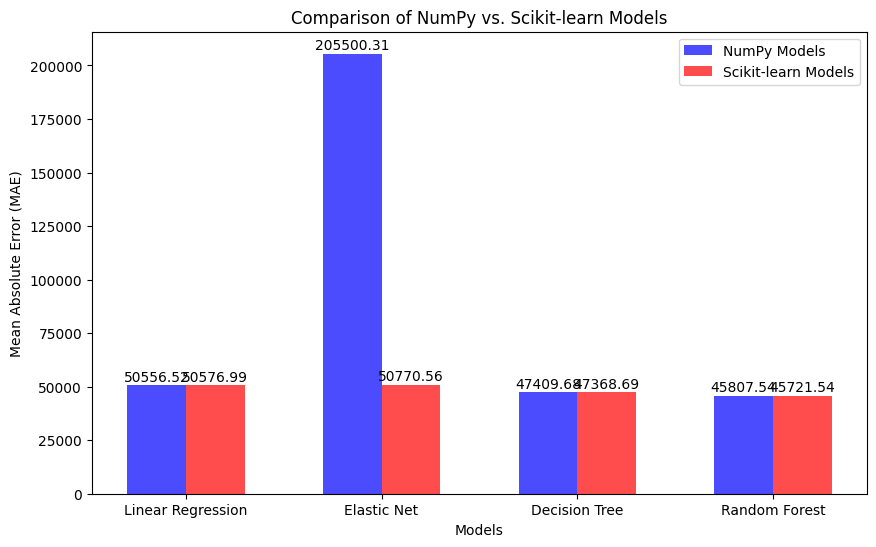

In [13]:
import matplotlib.pyplot as plt

mae_numpy = [mae_lr, mae_elastic, mae_dt, mae_rf]
mae_sklearn = [mae_lr_sklearn, mae_elastic_sklearn, mae_dt_sklearn, mae_rf_sklearn]
labels = ["Linear Regression", "Elastic Net", "Decision Tree", "Random Forest"]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mae_numpy, width, label="NumPy Models", color="b", alpha=0.7)
bars2 = ax.bar(x + width/2, mae_sklearn, width, label="Scikit-learn Models", color="r", alpha=0.7)

ax.set_xlabel("Models")
ax.set_ylabel("Mean Absolute Error (MAE)")
ax.set_title("Comparison of NumPy vs. Scikit-learn Models")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', fontsize=10, color="black")

plt.show()


## Conclusion

- Linear Regression & Elastic Net:

  The results of both NumPy and Scikit-learn implementations are almost identical, indicating that the linear regression algorithm was correctly implemented and performs well.

  However, the high MAE suggests that the data may contain significant noise or that the relationship is not entirely linear.

- Decision Tree & Random Forest:

  Both the Decision Tree and Random Forest models from Scikit-learn achieved slightly lower MAE compared to the NumPy-based implementations.

  This difference may be due to Scikit-learn's optimizations in decision splitting and tree combination.

- Random Forest performs the best:

  Among all models, Scikit-learn's Random Forest achieved the lowest MAE (~45,586), indicating better generalization.

  The NumPy version of Random Forest also performed well but may require further optimizations
